# Binning the mass transport along isobath in 3 degree bins

Binning the mass transport calculated by Christina into 3 degree bins for analysis against the CSHT 

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d

import xarray as xr
import cf_xarray as cfxr

In [2]:
client = Client(n_workers=24, memory_limit = '1400gb')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 48,Total memory: 30.56 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46353,Workers: 24
Dashboard: /proxy/8787/status,Total threads: 48
Started: Just now,Total memory: 30.56 TiB
Comm: tcp://127.0.0.1:37313,Total threads: 2
Dashboard: /proxy/33051/status,Memory: 1.27 TiB
Nanny: tcp://127.0.0.1:41573,


2025-01-21 16:41:18,685 - distributed.nanny - WARNING - Restarting worker
2025-01-21 16:41:18,733 - distributed.nanny - WARNING - Restarting worker
2025-01-21 16:41:18,822 - distributed.nanny - WARNING - Restarting worker
2025-01-21 16:41:19,126 - distributed.nanny - WARNING - Restarting worker
2025-01-21 16:41:20,133 - distributed.nanny - WARNING - Restarting worker


In [3]:
Mass_transports_dir  = '/g/data/e14/cs6673/PanAntarctic_AABW/data_analysis/'

filenamebase = 'vol_transp_across_1000m_isobath_panan'

start_time = '1999-01-01'
end_time = '2002-01-01'
time_slice=slice(start_time, end_time)

#importing volume transports
p01_MT = xr.open_mfdataset(Mass_transports_dir + filenamebase +'_01deg_jra55_ryf_1m_****.nc').sel(time=time_slice)
p005_MT = xr.open_mfdataset(Mass_transports_dir + filenamebase + '_005deg_jra55_ryf_fixed_runoff_1m_*.nc').sel(time=time_slice)



In [4]:
#panan01 daily as HT f(z,time) to colocate the isoabth points
src_p01 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').compute()
p01_HTmean=p01_HT.mean('time').compute()


#panan005 daily as HT f(z,time) to colocate the isoabth points
src_p005 = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/CSHT_month_rhoonline/*'

#importing panan01
import glob
gl =glob.glob(src_p005)
gl=sorted(gl)
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').compute()
p005_HTmean=p005_HT.mean('time').compute()

In [5]:
#corection factor for overlaying bins
factor01 = (p01_HTmean.unbinned_heat_transp_across_contour.sum() /(p01_HTmean.binned_cross_slope_heat_trans + p01_HTmean.zonal_convergence).sum()).compute().values
factor005 = (p005_HTmean.unbinned_heat_transp_across_contour.sum() /(p005_HTmean.binned_cross_slope_heat_trans + p005_HTmean.zonal_convergence).sum()).compute().values


##  Binning panan01

In [454]:
# convert to longitude coordinate and average into 3 degree longitude bins:
# in degrees:
bin_width = 3
bin_spacing = 0.25
lon_west = -280
lon_east = 80
lon_along_contour = np.array(p01_HTmean.lon_along_contour)
lat_along_contour = np.array(p01_HTmean.lat_along_contour)
p01_MT_np=np.array(p01_MT.vol_trans_across_contour.fillna(0))
# new coordinate and midpoints of longitude bins:
full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
n_bin_edges = len(full_lon_coord)

# sum into longitude bins:
# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
# on the isobath contour and sum continously along contour between defined indices.
# (i.e. lon_along_contour is not monotonic)
# find points on contour to define edges of longitude bins:
bin_edge_indices = np.zeros(n_bin_edges)
for lon_bin in range(n_bin_edges-1):
    # find first isobath point that has the right longitude:
    first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
    # then find all other isobath points with the same longitude as that first point:
    same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
    # we want the most southerly of these points on the same longitude line:
    bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]

# define east/west edges:
bin_edge_indices = bin_edge_indices.astype(int)
bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
n_bins = len(bin_edge_indices_west)

# sum heat transport from isobath coord into new longitude coord:
p01_MT_3degbins = np.zeros([36,99,n_bins])
for lon_bin in range(n_bins):
	MT0 = p01_MT_np[:,:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	p01_MT_3degbins[:,:,lon_bin] = np.nansum(MT0,axis=2) #* factor01 


# #same factor as heat
# p01_MT_3degbins = p01_MT_3degbins * factor01 

# ##month dependent factor
# p01_mass_factor =  p01_MT.vol_trans_across_contour.sum(('rho2_l','contour_index')).values / np.nansum(np.nansum(p01_MT_3degbins,axis = 2),axis = 1)
# p01_MT_3degbins = p01_MT_3degbins * np.transpose(np.tile(p01_mass_factor,[99,1428,1]),[2,0,1])

# #mean time factor
# p01_mass_factor =  p01_MT.vol_trans_across_contour.sum(('rho2_l','contour_index')).values / np.nansum(np.nansum(p01_MT_3degbins,axis = 2),axis = 1)
# p01_mass_factor_mean = np.mean(p01_mass_factor)
# p01_MT_3degbins = p01_MT_3degbins * p01_mass_factor_mean

#for me this seems like it should be the correct answer
##month and density layer dependent factor
p01_mass_factor =  p01_MT.vol_trans_across_contour.sum(('contour_index')).values /np.sum(p01_MT_3degbins,axis = 2)
p01_MT_3degbins = p01_MT_3degbins * np.transpose(np.tile(p01_mass_factor,[1428,1,1]),[1,2,0])


# ##density layer only dependent factor
# p01_mass_factor =  p01_MT.vol_trans_across_contour.sum(('contour_index')).values /np.nansum(p01_MT_3degbins,axis = 2)
# p01_mass_factor_mean = np.mean(p01_mass_factor,axis=0) #time mean
# p01_MT_3degbins = p01_MT_3degbins * np.transpose(np.tile(p01_mass_factor_mean,[1428,1,1]),[1,2,0])


  p01_mass_factor =  p01_MT.vol_trans_across_contour.sum(('contour_index')).values /np.sum(p01_MT_3degbins,axis = 2)



In [455]:
#Turning into Xarray for saving it
p01_MT_binned = p01_HT.binned_cross_slope_heat_trans.copy()
p01_MT_binned.values =p01_MT_3degbins
p01_MT_binned.name =  'MT_binned_SV'

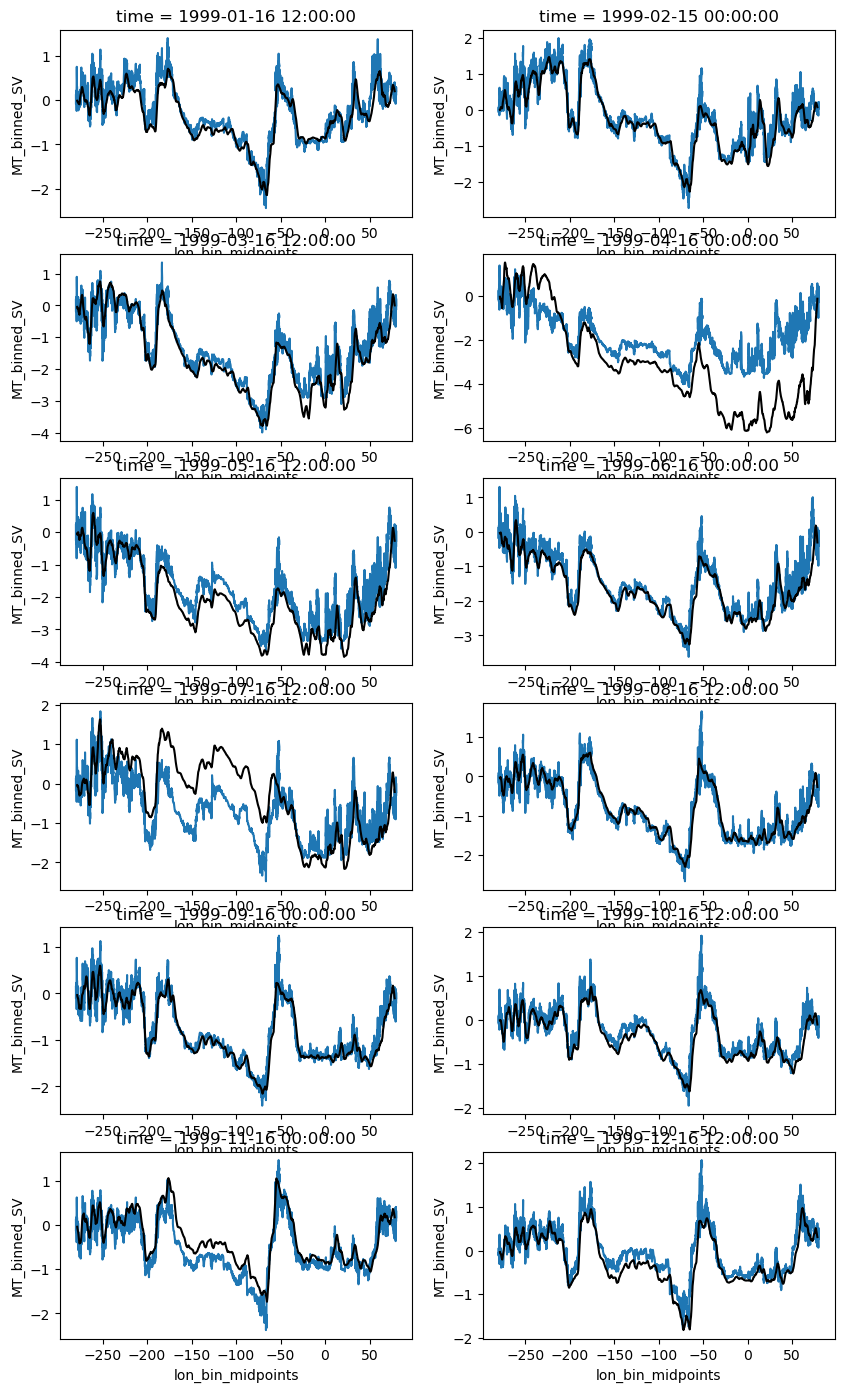

In [456]:
plt.figure(figsize=(10,17))
for timeind in range(12):
    plt.subplot(6,2,timeind+1)
    plt.plot(p01_MT.isel(time=timeind).lon, p01_MT.vol_trans_across_contour.isel(time=timeind).cumsum('contour_index').sum('rho2_l'),\
             label = 'unbinned')
    p01_MT_binned.isel(time=timeind).cumsum('lon_bin_midpoints').sum('rho2_l').plot(color='black', label = 'binned')



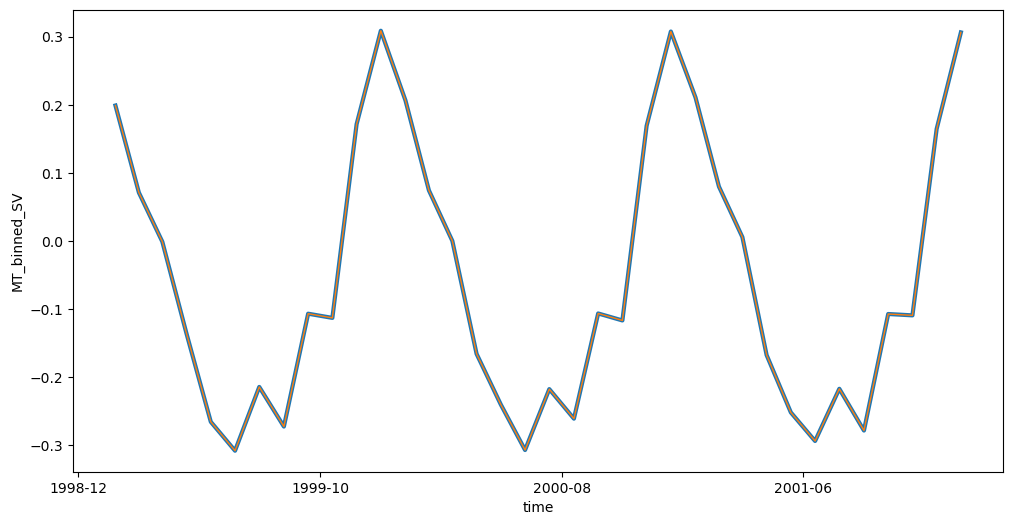

In [457]:
plt.figure(figsize=(12,6))
p01_MT.vol_trans_across_contour.sum('rho2_l').sum('contour_index').plot(linewidth=3)
p01_MT_binned.sum('rho2_l').sum('lon_bin_midpoints').plot(linewidth=1)

Sanity check.... does the binned data look reasonably close to the unbinned one?

Saving the panan01 data

In [80]:
base_savedir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
p01_MT_binned.to_netcdf(base_savedir +\
                        'panan01_rerun/EKE_along_contour/MT_binned_along_contour_panan01.nc')



##  Binning panan005

In [137]:
# convert to longitude coordinate and average into 3 degree longitude bins:
# in degrees:
del MT0
bin_width = 3
bin_spacing = 0.25
lon_west = -280
lon_east = 80
lon_along_contour = np.array(p005_HTmean.lon_along_contour)
lat_along_contour = np.array(p005_HTmean.lat_along_contour)
p005_MT_np=np.array(p005_MT.vol_trans_across_contour)
# new coordinate and midpoints of longitude bins:
full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
n_bin_edges = len(full_lon_coord)

# sum into longitude bins:
# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
# on the isobath contour and sum continously along contour between defined indices.
# (i.e. lon_along_contour is not monotonic)
# find points on contour to define edges of longitude bins:
bin_edge_indices = np.zeros(n_bin_edges)
for lon_bin in range(n_bin_edges-1):
    # find first isobath point that has the right longitude:
    first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
    # then find all other isobath points with the same longitude as that first point:
    same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
    # we want the most southerly of these points on the same longitude line:
    bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]

# define east/west edges:
bin_edge_indices = bin_edge_indices.astype(int)
bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
n_bins = len(bin_edge_indices_west)

# sum heat transport from isobath coord into new longitude coord:
p005_MT_3degbins = np.zeros([36,99,n_bins])
for lon_bin in range(n_bins):
	MT0 = p005_MT_np[:,:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
	p005_MT_3degbins[:,:,lon_bin] = np.sum(MT0,axis=2) * factor005



In [138]:
#Turning into Xarray for saving it
p005_MT_binned = p005_HT.binned_cross_slope_heat_trans.copy()
p005_MT_binned.values =p005_MT_3degbins
p005_MT_binned.name =  'MT_binned_SV'

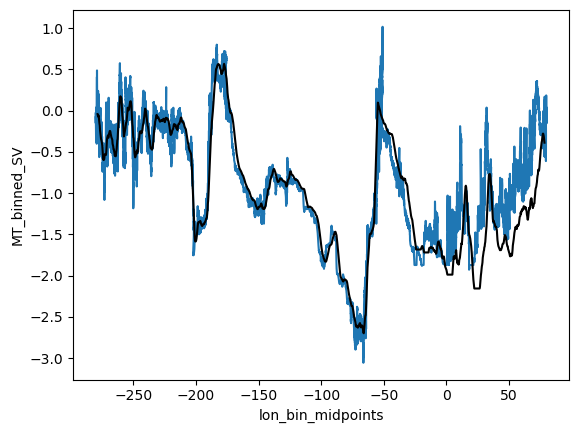

In [142]:
plt.plot(p005_MT.isel(time=0).lon, p005_MT.vol_trans_across_contour.mean('time').sum('rho2_l').cumsum(),\
        label = 'unbinned')
p005_MT_binned.mean('time').sum('rho2_l').cumsum().plot(color='black', label = 'binned')